# Hierarchical Clustering

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values

## Using the dendrogram to find the optimal number of clusters

In [ ]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))

**sch.linkage(X, method='ward')**

Esto construye la estructura jerárquica del clustering.
* Toma tus datos X (filas = observaciones, columnas = variables).
* Parte con cada punto como un cluster (al inicio tienes N clusters).
* Luego va uniendo clusters paso a paso hasta que queda un solo cluster.
* En cada paso decide “qué dos clusters unir” según el criterio del método.

**¿Qué hace method='ward'?**

Ward elige la unión que menos aumenta la variación interna de los clusters.

Es decir, une los dos grupos cuya fusión hace que los clusters sigan siendo lo más “compactos” posible.

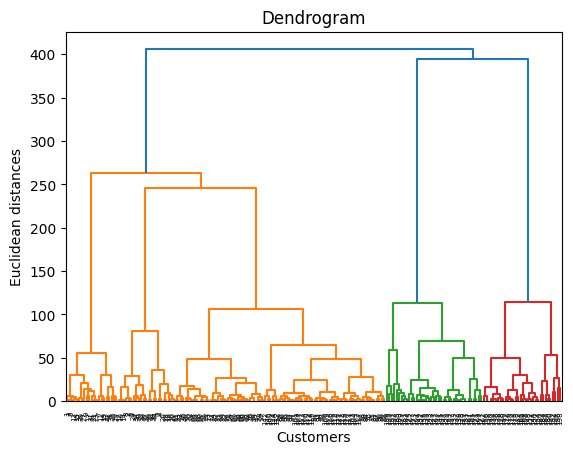

In [3]:
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

En un dendrograma:

* Eje X → observaciones (clientes)
* Eje Y → distancia a la que se fusionan los clusters

Cada unión horizontal indica cuándo dos grupos se fusionan



En el dendrograma buscamos el mayor salto vertical entre fusiones de clusters.

En tu gráfico aparecen tres niveles importantes aproximadamente en estas alturas:

fusiones pequeñas: 0 – 120

fusiones intermedias: 120 – 250

fusiones grandes: ≈ 400

Si quieres 5 clusters, el corte debe hacerse bastante abajo, antes de que muchos clusters se empiecen a fusionar.

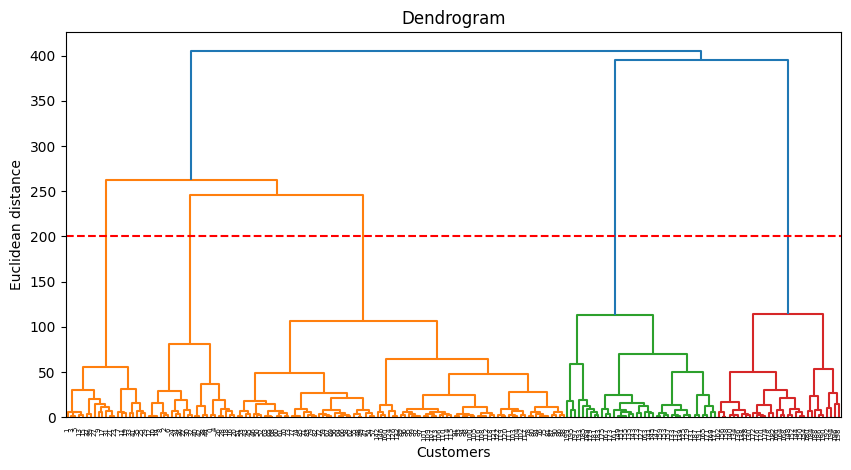

In [5]:
plt.figure(figsize=(10,5))

sch.dendrogram(sch.linkage(X, method='ward'))

plt.axhline(y=200, color='red', linestyle='--')  # línea de corte
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distance')

plt.show()

## Training the Hierarchical Clustering model on the dataset

In [4]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5, metric = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(X)

## Visualising the clusters

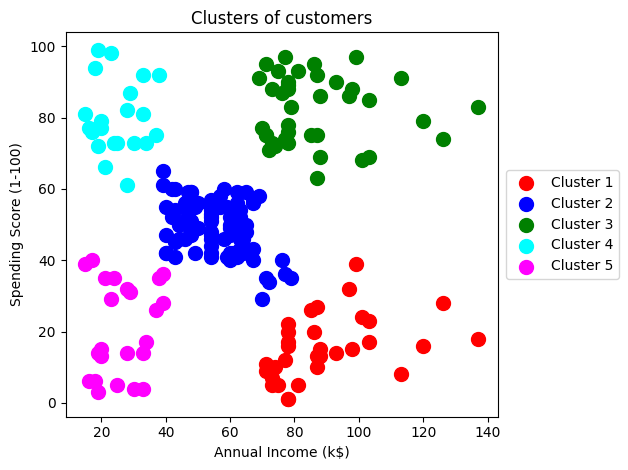

In [9]:
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s=100, c='magenta', label='Cluster 5')

plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
plt.tight_layout()
plt.show()